# Notebook 2:
### Demand Forecasting by Drug Class

**Purpose**

This notebook generates daily prescription demand forecasts at the drug class level. These forecasts simulate forward-looking workload expectations used for staffing and operational planning.

#### Modeling and feature outputs
- `daily_class_features.csv`
- `daily_demand_by_class.csv`
- `model_metrics_by_class.csv`

#### Forecast outputs
- `predictions_daily_class.csv`
- `forecast_6m_by_class.csv`

#### Operational planning outputs
- `forecast_demand_by_class_day.csv`
- `inventory_suggestions_by_class.csv`

**Key responsibilities**
- Aggregates historical prescription activity
- Produces class-level daily demand forecasts
- Standardizes forecast schema for BI consumption
- Aligns forecast totals with observed prescription volume

In [13]:
# --- Config (paths) ---
from pathlib import Path

from pathlib import Path
import pandas as pd
import numpy as np
from pathlib import Path
import pandas as pd
import numpy as np

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

DATA_GEN  = REPO_ROOT / "data" / "generated"
DATA_REAL = REPO_ROOT / "data" / "real"
OUT_DIR   = REPO_ROOT / "forecast"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def first_existing(candidates):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p
    return None

# Core
P_RX = first_existing([
    DATA_GEN / "prescriptions.csv",
    REPO_ROOT / "prescriptions.csv",
])

# Real data sources
P_PRODUCTS = first_existing([
    DATA_REAL / "products.csv",
    REPO_ROOT / "products.csv",
])

P_CLASS_MAP = first_existing([
    DATA_GEN / "drug_class_map.csv",
    REPO_ROOT / "drug_class_map.csv",
    REPO_ROOT / "bi_outputs" / "drug_class_map.csv",
])

P_RX_BY_CLASS = first_existing([
    DATA_REAL / "prescriptions_by_class.csv",
    REPO_ROOT / "prescriptions_by_class.csv",
])

P_REF_DRUGS = first_existing([
    DATA_REAL / "ref_drugs.csv",
    REPO_ROOT / "ref_drugs.csv",
])

P_REF_DRUGNAME_CLASS = first_existing([
    DATA_REAL / "ref_drugname_class_map.csv",
    REPO_ROOT / "ref_drugname_class_map.csv",
])

print("REPO_ROOT:", REPO_ROOT)
print("DATA_GEN exists:", DATA_GEN.exists(), DATA_GEN)
print("DATA_REAL exists:", DATA_REAL.exists(), DATA_REAL)
print("P_RX:", P_RX)
print("P_PRODUCTS:", P_PRODUCTS)
print("P_CLASS_MAP:", P_CLASS_MAP)
print("P_RX_BY_CLASS:", P_RX_BY_CLASS)
print("P_REF_DRUGS:", P_REF_DRUGS)
print("P_REF_DRUGNAME_CLASS:", P_REF_DRUGNAME_CLASS)

if P_RX is None:
    raise FileNotFoundError("prescriptions.csv not found. Expected data/generated/prescriptions.csv")

REPO_ROOT: /Users/selenadavis/PythonProject1/PharmacyOperationsOptimization
DATA_GEN exists: True /Users/selenadavis/PythonProject1/PharmacyOperationsOptimization/data/generated
DATA_REAL exists: True /Users/selenadavis/PythonProject1/PharmacyOperationsOptimization/data/real
P_RX: /Users/selenadavis/PythonProject1/PharmacyOperationsOptimization/data/generated/prescriptions.csv
P_PRODUCTS: /Users/selenadavis/PythonProject1/PharmacyOperationsOptimization/data/real/products.csv
P_CLASS_MAP: /Users/selenadavis/PythonProject1/PharmacyOperationsOptimization/data/real/drug_class_map.csv
P_RX_BY_CLASS: /Users/selenadavis/PythonProject1/PharmacyOperationsOptimization/data/real/prescriptions_by_class.csv
P_REF_DRUGS: /Users/selenadavis/PythonProject1/PharmacyOperationsOptimization/data/real/ref_drugs.csv
P_REF_DRUGNAME_CLASS: /Users/selenadavis/PythonProject1/PharmacyOperationsOptimization/data/real/ref_drugname_class_map.csv


In [14]:
# --- Imports ---
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def first_existing(paths):
    """Return first Path that exists from a list of Path objects."""
    for p in paths:
        if p is not None and Path(p).exists():
            return Path(p)
    return None

def norm_name(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9\s]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

In [15]:
# --- Helpers ---
def _clean_class(x) -> str:
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return ""
    s = str(x).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def detect_first(df: pd.DataFrame, candidates: list[str], what: str) -> str:
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"No {what} column found. Tried: {candidates}. Got columns: {df.columns.tolist()}")

def standardize_prescriptions(rx: pd.DataFrame) -> pd.DataFrame:
    rx = rx.copy()

    date_col = None
    for c in ["RefillDate", "FillDate", "Date"]:
        if c in rx.columns:
            date_col = c
            break
    if date_col is None:
        raise ValueError("prescriptions.csv must include RefillDate or FillDate or Date")

    qty_col = detect_first(rx, ["QuantityDispensed", "Quantity", "Qty", "Units"], "quantity")
    drugid_col = detect_first(rx, ["DrugID", "NDC", "NDC_2SEG"], "DrugID")
    drugname_col = detect_first(rx, ["DrugName", "ProductName", "Name"], "DrugName")

    rx["Date"] = pd.to_datetime(rx[date_col], errors="coerce")
    rx["Quantity"] = pd.to_numeric(rx[qty_col], errors="coerce").fillna(0.0)
    rx["DrugID"] = rx[drugid_col].astype(str).str.strip()
    rx["DrugName"] = rx[drugname_col].astype(str).str.strip()

    rx = rx.dropna(subset=["Date"])
    return rx[["Date","DrugID","DrugName","Quantity"]]

def load_ref_mapping(path: Path) -> pd.DataFrame:
    ref = pd.read_csv(path, low_memory=False)

    lower = {c.lower(): c for c in ref.columns}
    id_candidates = [
        lower.get("drugid"), lower.get("ndc"), lower.get("ndc_2seg"),
        lower.get("drugid_original"), lower.get("ndc2seg")
    ]
    id_candidates = [c for c in id_candidates if c]

    class_candidates = [
        lower.get("drugclass"), lower.get("pharm_classes"), lower.get("pharm_class"),
        lower.get("class"), lower.get("pharm_classes_normalized")
    ]
    class_candidates = [c for c in class_candidates if c]

    if not class_candidates:
        raise ValueError(f"ref_drugs.csv has no class column. Columns: {ref.columns.tolist()}")

    class_col = class_candidates[0]
    name_col = lower.get("drugname") or lower.get("name") or lower.get("productname")

    cols = []
    if id_candidates:
        id_col = id_candidates[0]
        cols.append(id_col)
    else:
        id_col = None

    if name_col:
        cols.append(name_col)

    cols.append(class_col)
    m = ref[cols].copy()

    if id_col:
        m = m.rename(columns={id_col: "DrugID"})
        m["DrugID"] = m["DrugID"].astype(str).str.strip()
    else:
        m["DrugID"] = ""

    if name_col:
        m = m.rename(columns={name_col: "DrugName"})
        m["DrugName"] = m["DrugName"].astype(str).str.strip()
    else:
        m["DrugName"] = ""

    m = m.rename(columns={class_col: "DrugClass"})
    m["DrugClass"] = m["DrugClass"].apply(_clean_class)

    m = m[m["DrugClass"] != ""].drop_duplicates()
    return m[["DrugID","DrugName","DrugClass"]]

In [16]:
# --- 1) Load prescriptions + attach DrugClass ---
import pandas as pd
import numpy as np

def clean_id(s):
    s = str(s)
    s = s.replace("\u200b", "").replace("\ufeff", "").strip()
    s = "".join(ch for ch in s if ch.isdigit() or ch == "-")
    return s

def standardize_prescriptions(rx: pd.DataFrame) -> pd.DataFrame:
    rx = rx.copy()

    date_col = None
    for c in ["FillDate", "RefillDate", "Date"]:
        if c in rx.columns:
            date_col = c
            break
    if date_col is None:
        raise ValueError("prescriptions.csv must include FillDate or RefillDate or Date")

    rx["Date"] = pd.to_datetime(rx[date_col], errors="coerce").dt.normalize()
    rx = rx.loc[rx["Date"].notna()].copy()

    if "Quantity" not in rx.columns:
        if "QuantityDispensed" in rx.columns:
            rx["Quantity"] = pd.to_numeric(rx["QuantityDispensed"], errors="coerce").fillna(0.0)
        else:
            rx["Quantity"] = 1.0

    rx["DrugID_clean"] = rx["DrugID"].map(clean_id) if "DrugID" in rx.columns else None

    return rx

def load_drugclass_mapping() -> pd.DataFrame:
    # Priority: explicit DrugID mapping file, then prescriptions_by_class, then ref_drugs, then drugname map
    if P_CLASS_MAP is not None:
        m = pd.read_csv(P_CLASS_MAP, low_memory=False)
        # expect: DrugID_clean + pharm_classes (or DrugClass)
        col_id = next((c for c in ["DrugID_clean", "DrugID"] if c in m.columns), None)
        col_cls = next((c for c in ["pharm_classes", "DrugClass", "Class"] if c in m.columns), None)
        if col_id is None or col_cls is None:
            raise ValueError(f"drug_class_map missing required columns. Got: {list(m.columns)}")
        m = m.rename(columns={col_id: "DrugID_clean", col_cls: "DrugClass"})
        m["DrugID_clean"] = m["DrugID_clean"].map(clean_id)
        m["DrugClass"] = m["DrugClass"].astype(str).str.strip()
        return m[["DrugID_clean", "DrugClass"]].dropna()

    if P_RX_BY_CLASS is not None:
        m = pd.read_csv(P_RX_BY_CLASS, low_memory=False)
        col_id = next((c for c in ["DrugID_clean", "DrugID"] if c in m.columns), None)
        col_cls = next((c for c in ["DrugClass", "pharm_classes", "Class"] if c in m.columns), None)
        if col_id is None or col_cls is None:
            raise ValueError(f"prescriptions_by_class missing required columns. Got: {list(m.columns)}")
        m = m.rename(columns={col_id: "DrugID_clean", col_cls: "DrugClass"})
        m["DrugID_clean"] = m["DrugID_clean"].map(clean_id)
        m["DrugClass"] = m["DrugClass"].astype(str).str.strip()
        return m[["DrugID_clean", "DrugClass"]].dropna().drop_duplicates()

    if P_REF_DRUGS is not None:
        m = pd.read_csv(P_REF_DRUGS, low_memory=False)
        col_id = next((c for c in ["DrugID_clean", "DrugID", "productndc"] if c in m.columns), None)
        col_cls = next((c for c in ["DrugClass", "pharm_classes", "Class"] if c in m.columns), None)
        if col_id is None or col_cls is None:
            raise ValueError(f"ref_drugs missing required columns. Got: {list(m.columns)}")
        m = m.rename(columns={col_id: "DrugID_clean", col_cls: "DrugClass"})
        m["DrugID_clean"] = m["DrugID_clean"].map(clean_id)
        m["DrugClass"] = m["DrugClass"].astype(str).str.strip()
        return m[["DrugID_clean", "DrugClass"]].dropna().drop_duplicates()

    if P_REF_DRUGNAME_CLASS is not None:
        m = pd.read_csv(P_REF_DRUGNAME_CLASS, low_memory=False)
        col_name = next((c for c in ["DrugName", "drugname", "proprietaryname", "nonproprietaryname"] if c in m.columns), None)
        col_cls = next((c for c in ["DrugClass", "pharm_classes", "Class"] if c in m.columns), None)
        if col_name is None or col_cls is None:
            raise ValueError(f"ref_drugname_class_map missing required columns. Got: {list(m.columns)}")
        m = m.rename(columns={col_name: "DrugName", col_cls: "DrugClass"})
        m["DrugName"] = m["DrugName"].astype(str).str.strip()
        m["DrugClass"] = m["DrugClass"].astype(str).str.strip()
        return m[["DrugName", "DrugClass"]].dropna().drop_duplicates()

    raise FileNotFoundError(
        "No mapping source found. Expected one of: data/real/drug_class_map.csv, prescriptions_by_class.csv, ref_drugs.csv, ref_drugname_class_map.csv"
    )

# ---- Load and map ----
rx_raw = pd.read_csv(P_RX, low_memory=False)
rx = standardize_prescriptions(rx_raw)

m = load_drugclass_mapping()

if "DrugID_clean" in m.columns:
    rx_mapped = rx.merge(m, on="DrugID_clean", how="left")
elif "DrugName" in m.columns:
    rx_mapped = rx.merge(m, on="DrugName", how="left")
else:
    raise ValueError("Mapping table has no usable key columns after standardization.")

rx_mapped["DrugClass"] = rx_mapped["DrugClass"].fillna("Unmapped")

print("rx_mapped shape:", rx_mapped.shape)
print("Unmapped rows:", int((rx_mapped["DrugClass"] == "Unmapped").sum()), "of", len(rx_mapped))
rx_mapped.head()

rx_mapped shape: (12000, 13)
Unmapped rows: 0 of 12000


,RxID,DrugID,DrugName,QuantityDispensed,RefillDate,Cost,PatientID,FillDate,InsuranceType,Date,Quantity,DrugID_clean,DrugClass
0,RX0000001,0098-0098-78,Lisinopril 50 mg capsule,60,2024-07-15,214.62,P00109,2024-07-15,Commercial,2024-07-15,60,0098-0098-78,"Angiotensin Converting Enzyme Inhibitor, Angio..."
1,RX0000002,0038-0038-18,Amlodipine 250 mg inhaler,58,2024-11-26,248.54,P00122,2024-11-26,Medicare,2024-11-26,58,0038-0038-18,"Cytochrome P450 2C8 Inhibitors, Decreased Plat..."
2,RX0000003,0191-0191-01,Sertraline 50 mg capsule,12,2024-03-01,15.82,P00369,2024-03-01,Commercial,2024-03-01,12,0191-0191-01,"Thyroxine, l-Thyroxine"
3,RX0000004,0003-0003-33,Amoxicillin 250 mg inhaler,99,2024-03-21,44.41,P00377,2024-03-21,Cash,2024-03-21,99,0003-0003-33,"Penicillin-class Antibacterial, Penicillins"
4,RX0000005,0016-0016-76,Prednisone 100 mg tablet,24,2024-06-28,181.56,P00104,2024-06-28,Cash,2024-06-28,24,0016-0016-76,"Biguanide, Biguanides"


In [17]:
# --- 2) Aggregate daily demand by DrugClass ---
daily_class = (
    rx_mapped
    .groupby(["DrugClass","Date"], as_index=False)["Quantity"]
    .sum()
    .rename(columns={"Quantity":"Demand"})
    .sort_values(["DrugClass","Date"])
)

all_days = pd.date_range(daily_class["Date"].min(), daily_class["Date"].max(), freq="D")
classes = daily_class["DrugClass"].unique()

panel = (
    pd.MultiIndex.from_product([classes, all_days], names=["DrugClass","Date"])
    .to_frame(index=False)
    .merge(daily_class, on=["DrugClass","Date"], how="left")
)
panel["Demand"] = panel["Demand"].fillna(0.0)

daily_class = panel.sort_values(["DrugClass","Date"]).reset_index(drop=True)
daily_class.to_csv(OUT_DIR / "daily_demand_by_class.csv", index=False)
daily_class.to_csv(OUT_DIR / "predictions_daily_class.csv", index=False)

daily_class.head()

,DrugClass,Date,Demand
0,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2023-01-01,106.0
1,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2023-01-02,66.0
2,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2023-01-03,0.0
3,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2023-01-04,194.0
4,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2023-01-05,35.0


In [18]:
# --- 3) Feature engineering ---
df = daily_class.copy()

df["lag_1"]  = df.groupby("DrugClass")["Demand"].shift(1)
df["lag_7"]  = df.groupby("DrugClass")["Demand"].shift(7)
df["lag_14"] = df.groupby("DrugClass")["Demand"].shift(14)

df["ma_7"]  = df.groupby("DrugClass")["Demand"].shift(1).rolling(7).mean().reset_index(level=0, drop=True)
df["ma_14"] = df.groupby("DrugClass")["Demand"].shift(1).rolling(14).mean().reset_index(level=0, drop=True)

df["dow"] = df["Date"].dt.dayofweek
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day

feature_cols = ["lag_1","lag_7","lag_14","ma_7","ma_14","dow","month","day"]
df[feature_cols] = df[feature_cols].fillna(0.0)

daily_class_features = df
daily_class_features.to_csv(OUT_DIR / "daily_class_features.csv", index=False)

daily_class_features.head()

,DrugClass,Date,Demand,lag_1,lag_7,lag_14,ma_7,ma_14,dow,month,day
0,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2023-01-01,106.0,0.0,0.0,0.0,0.0,0.0,6,1,1
1,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2023-01-02,66.0,106.0,0.0,0.0,0.0,0.0,0,1,2
2,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2023-01-03,0.0,66.0,0.0,0.0,0.0,0.0,1,1,3
3,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2023-01-04,194.0,0.0,0.0,0.0,0.0,0.0,2,1,4
4,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2023-01-05,35.0,194.0,0.0,0.0,0.0,0.0,3,1,5


In [23]:
# --- Modeling configuration ---
TOP_N_CLASSES_TO_MODEL = globals().get("TOP_N_CLASSES_TO_MODEL", 10)
TEST_DAYS = globals().get("TEST_DAYS", 30)
RF_N_ESTIMATORS = globals().get("RF_N_ESTIMATORS", 200)
RF_RANDOM_STATE = globals().get("RF_RANDOM_STATE", 42)

In [24]:
# --- 4) Train/test + baselines + RandomForest (top classes) ---
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

def time_split(one_class_df: pd.DataFrame, test_days: int):
    cutoff = one_class_df["Date"].max() - pd.Timedelta(days=test_days)
    train = one_class_df[one_class_df["Date"] <= cutoff].copy()
    test  = one_class_df[one_class_df["Date"] >  cutoff].copy()
    return train, test

def metrics(y_true, y_pred):
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(sqrt(mean_squared_error(y_true, y_pred)))
    denom = np.maximum(1e-9, np.abs(y_true))
    mape = float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)
    return mae, rmse, mape

class_totals = daily_class.groupby("DrugClass")["Demand"].sum().sort_values(ascending=False)
classes_to_model = class_totals.head(TOP_N_CLASSES_TO_MODEL).index.tolist()

rows = []
models = {}

for cls in classes_to_model:
    sub = daily_class_features[daily_class_features["DrugClass"] == cls].copy()
    train, test = time_split(sub, TEST_DAYS)
    X_train, y_train = train[feature_cols], train["Demand"].values
    X_test,  y_test  = test[feature_cols],  test["Demand"].values

    naive = test["lag_1"].values
    ma7   = test["ma_7"].values

    naive_mae, naive_rmse, naive_mape = metrics(y_test, naive)
    ma7_mae,   ma7_rmse,   ma7_mape   = metrics(y_test, ma7)

    rf = RandomForestRegressor(
        n_estimators=RF_N_ESTIMATORS,
        random_state=RF_RANDOM_STATE,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)

    rf_mae, rf_rmse, rf_mape = metrics(y_test, pred)

    rows.append({
        "DrugClass": cls,
        "TotalDemand": float(class_totals.loc[cls]),
        "Naive_MAE": naive_mae, "Naive_RMSE": naive_rmse, "Naive_MAPE%": naive_mape,
        "MA7_MAE": ma7_mae, "MA7_RMSE": ma7_rmse, "MA7_MAPE%": ma7_mape,
        "RF_MAE": rf_mae, "RF_RMSE": rf_rmse, "RF_MAPE%": rf_mape,
    })
    models[cls] = rf

metrics_df = pd.DataFrame(rows).sort_values("TotalDemand", ascending=False)
metrics_df.to_csv(OUT_DIR / "model_metrics_by_class.csv", index=False)

metrics_df.head(10)

,DrugClass,TotalDemand,Naive_MAE,Naive_RMSE,Naive_MAPE%,MA7_MAE,MA7_RMSE,MA7_MAPE%,RF_MAE,RF_RMSE,RF_MAPE%
0,"Penicillin-class Antibacterial, Penicillins",93072.0,101.133333,122.455162,1.026667e+12,98.428571,118.018447,1.569048e+12,91.330833,108.980361,1.188083e+12
1,"Angiotensin Converting Enzyme Inhibitor, Angio...",77506.0,98.933333,123.255561,1.870000e+12,65.400000,82.063241,1.744286e+12,66.105333,80.146877,2.035917e+12
2,"Insulin Analog, Insulin",65256.0,79.033333,103.519563,2.613333e+12,55.042857,73.560623,1.935714e+12,60.145833,76.251030,2.601633e+12
3,"Biguanide, Biguanides",61910.0,102.333333,142.682632,1.263333e+12,69.657143,105.639323,1.893810e+12,81.214000,105.495510,2.604867e+12
4,"Cytochrome P450 2C8 Inhibitors, Decreased Plat...",54299.0,80.800000,104.081378,2.340000e+12,62.519048,82.552712,2.256190e+12,59.602500,74.277665,2.476333e+12
5,"Cytochrome P450 2C19 Inhibitors, Proton Pump I...",53756.0,89.700000,124.645765,2.823333e+12,72.085714,90.597931,2.422381e+12,70.413167,89.349340,2.630867e+12
6,"Corticosteroid Hormone Receptor Agonists, Cort...",51308.0,81.733333,110.939623,3.056667e+12,71.157143,84.891147,2.483333e+12,69.625333,76.997633,3.281217e+12
7,"Anti-epileptic Agent, Decreased Central Nervou...",50601.0,84.400000,116.934455,2.926667e+12,71.261905,86.853638,2.461429e+12,81.245000,96.673619,4.303400e+12
8,"Increased Diuresis at Loop of Henle, Loop Diur...",49063.0,75.433333,102.579238,1.286667e+12,60.714286,77.532455,1.600000e+12,63.814167,74.745168,1.848350e+12
9,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",48145.0,101.100000,132.964782,2.406667e+12,80.371429,108.278251,2.109524e+12,64.855167,92.749749,1.667467e+12


In [28]:
# --- Config defaults ---
HORIZON_DAYS = globals().get("HORIZON_DAYS", 180)

required = [
    "classes_to_model",
    "models",
    "daily_class",
    "feature_cols",
    "OUT_DIR"
]

for name in required:
    print(f"{name} exists:", name in globals())

classes_to_model exists: True
models exists: True
daily_class exists: True
feature_cols exists: True
OUT_DIR exists: True


In [27]:
# --- 5) Roll-forward 6-month forecast (RandomForest, iterative) ---
fcst_rows = []

for cls in classes_to_model:
    model = models[cls]
    hist = daily_class[daily_class["DrugClass"] == cls][["Date","Demand"]].copy()
    last_date = hist["Date"].max()
    future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=HORIZON_DAYS, freq="D")

    demand_series = hist.set_index("Date")["Demand"].astype(float).copy()

    for d in future_dates:
        lag_1  = float(demand_series.get(d - pd.Timedelta(days=1), 0.0))
        lag_7  = float(demand_series.get(d - pd.Timedelta(days=7), 0.0))
        lag_14 = float(demand_series.get(d - pd.Timedelta(days=14), 0.0))
        past_7  = demand_series.reindex(pd.date_range(d - pd.Timedelta(days=7), d - pd.Timedelta(days=1), freq="D")).fillna(0.0)
        past_14 = demand_series.reindex(pd.date_range(d - pd.Timedelta(days=14), d - pd.Timedelta(days=1), freq="D")).fillna(0.0)
        ma_7  = float(past_7.mean())
        ma_14 = float(past_14.mean())

        X = pd.DataFrame([{
            "lag_1": lag_1, "lag_7": lag_7, "lag_14": lag_14,
            "ma_7": ma_7, "ma_14": ma_14,
            "dow": d.dayofweek, "month": d.month, "day": d.day
        }])[feature_cols]

        yhat = float(model.predict(X)[0])
        yhat = max(0.0, yhat)

        demand_series.loc[d] = yhat
        fcst_rows.append({"DrugClass": cls, "Date": d, "ForecastDemand": yhat})

forecast_df = pd.DataFrame(fcst_rows).sort_values(["DrugClass","Date"])
forecast_df.to_csv(OUT_DIR / "forecast_6m_by_class.csv", index=False)

forecast_df.head()

,DrugClass,Date,ForecastDemand
1620,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2024-12-31,85.645
1621,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2025-01-01,71.840
1622,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2025-01-02,95.475
1623,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2025-01-03,77.305
1624,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2025-01-04,79.670


In [29]:
# --- 6) Simple inventory suggestions by class (forecast proxy) ---
avg_fcst = forecast_df.groupby("DrugClass")["ForecastDemand"].mean().rename("AvgDailyForecast")
std_fcst = forecast_df.groupby("DrugClass")["ForecastDemand"].std(ddof=0).fillna(0.0).rename("StdDailyForecast")

inv_suggest = pd.concat([avg_fcst, std_fcst], axis=1).reset_index()

LEAD_TIME_DAYS = 7
SAFETY_Z = 1.65

inv_suggest["LeadTimeDemand"] = inv_suggest["AvgDailyForecast"] * LEAD_TIME_DAYS
inv_suggest["SafetyStock"] = SAFETY_Z * inv_suggest["StdDailyForecast"] * np.sqrt(LEAD_TIME_DAYS)
inv_suggest["SuggestedOnHand"] = inv_suggest["LeadTimeDemand"] + inv_suggest["SafetyStock"]

inv_suggest = inv_suggest.sort_values("SuggestedOnHand", ascending=False)
inv_suggest.to_csv(OUT_DIR / "inventory_suggestions_by_class.csv", index=False)

inv_suggest.head(10)

,DrugClass,AvgDailyForecast,StdDailyForecast,LeadTimeDemand,SafetyStock,SuggestedOnHand
9,"Penicillin-class Antibacterial, Penicillins",115.446778,25.290244,808.127444,110.404299,918.531743
1,"Angiotensin Converting Enzyme Inhibitor, Angio...",110.354528,22.431795,772.481694,97.925771,870.407465
8,"Insulin Analog, Insulin",95.168222,15.612877,666.177556,68.157855,734.335410
3,"Biguanide, Biguanides",92.447583,11.391253,647.133083,49.728399,696.861482
6,"Cytochrome P450 2C8 Inhibitors, Decreased Plat...",80.477333,21.861189,563.341333,95.434794,658.776128
5,"Cytochrome P450 2C19 Inhibitors, Proton Pump I...",76.716194,17.673121,537.013361,77.151828,614.165189
4,"Corticosteroid Hormone Receptor Agonists, Cort...",76.559167,16.189595,535.914167,70.675511,606.589678
2,"Anti-epileptic Agent, Decreased Central Nervou...",74.155944,14.108647,519.091611,61.591151,580.682763
7,"Increased Diuresis at Loop of Henle, Loop Diur...",70.416389,14.919614,492.914722,65.131419,558.046142
0,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",62.522472,11.134312,437.657306,48.606722,486.264028


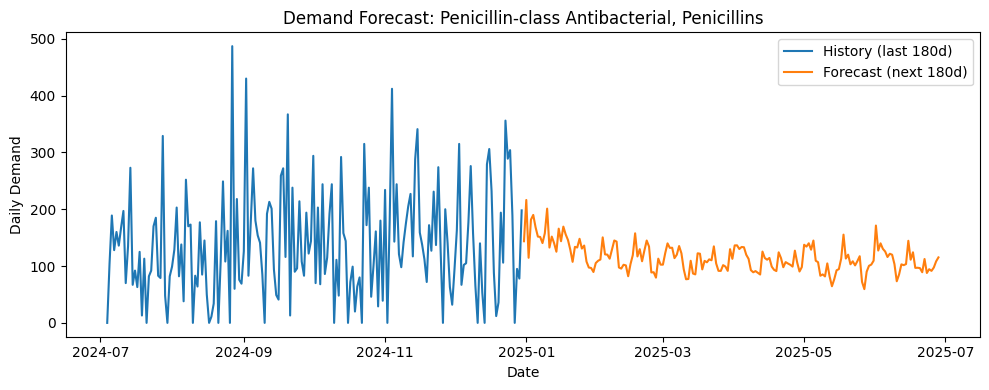

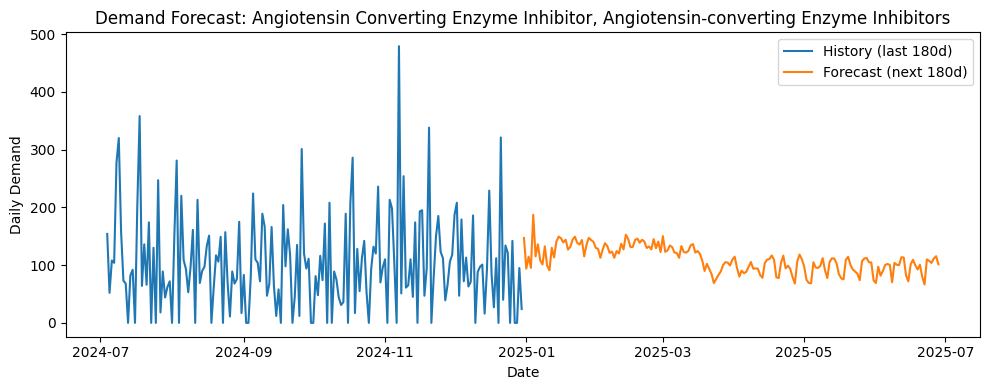

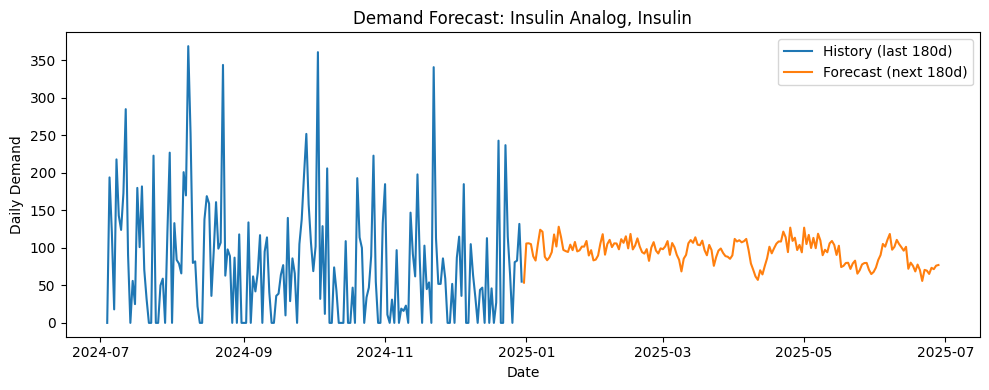

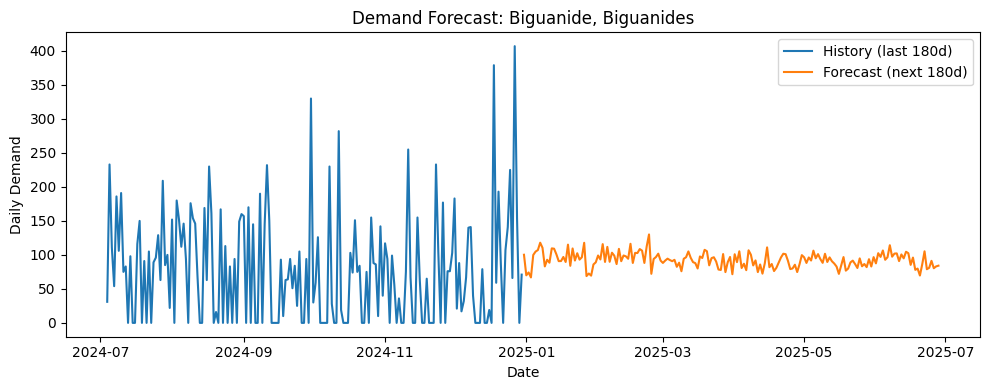

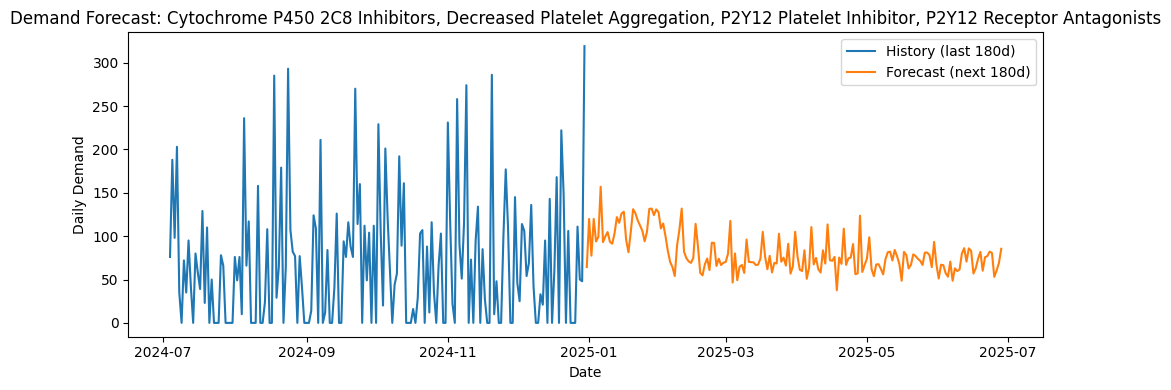

In [30]:
# --- 7) Quick sanity plots (top 5 classes) ---
top5 = metrics_df.sort_values("TotalDemand", ascending=False)["DrugClass"].head(5).tolist()

for cls in top5:
    sub_hist = daily_class[daily_class["DrugClass"] == cls].set_index("Date")["Demand"]
    sub_fcst = forecast_df[forecast_df["DrugClass"] == cls].set_index("Date")["ForecastDemand"]

    plt.figure(figsize=(10,4))
    plt.plot(sub_hist.tail(180), label="History (last 180d)")
    plt.plot(sub_fcst, label="Forecast (next 180d)")
    plt.title(f"Demand Forecast: {cls}")
    plt.xlabel("Date")
    plt.ylabel("Daily Demand")
    plt.legend()
    plt.tight_layout()
    plt.show()